# 👁️ Eye State Detection - MRL Eye Dataset
**Model:** MobileNetV2 alpha=0.35 | **Input:** 32×32 | **Classes:** Open / Closed

---
### ⚡ Trước khi chạy:
1. Vào **Runtime → Change runtime type → T4 GPU**
2. Chạy từng cell theo thứ tự từ trên xuống

## 🔧 BƯỚC 0: Kiểm tra GPU & Cài đặt thư viện

In [ ]:
# Kiểm tra GPU
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU sẵn sàng: {[g.name for g in gpus]}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠️  Không có GPU! Vào Runtime → Change runtime type → T4 GPU')

print(f'TensorFlow version: {tf.__version__}')

✅ GPU sẵn sàng: ['/physical_device:GPU:0']
TensorFlow version: 2.19.0


In [ ]:
# Cài thư viện cần thiết (Colab đã có sẵn hầu hết)
!pip install -q kaggle seaborn scikit-learn opencv-python-headless
print('✅ Thư viện đã cài xong')

✅ Thư viện đã cài xong


## 📦 BƯỚC 1: Tải Dataset từ Kaggle

### Cách lấy Kaggle API Key:
1. Vào [kaggle.com](https://www.kaggle.com) → Account → **Create New Token**
2. File `kaggle.json` sẽ được tải về máy
3. Upload file đó lên Colab bằng cell bên dưới

In [ ]:
# Upload file kaggle.json từ máy tính của bạn
from google.colab import files
import os

print('📤 Hãy upload file kaggle.json từ máy tính...')
uploaded = files.upload()

# Cài đặt kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle API key đã được cài đặt')

📤 Hãy upload file kaggle.json từ máy tính...


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API key đã được cài đặt


In [ ]:
# ============================================================
# TẢI DATASET TỪ KAGGLE
# Dataset: MRL Eye Dataset
# Link: https://www.kaggle.com/datasets/imadeddinedjerarda/mrl-eye-dataset
# ============================================================

KAGGLE_DATASET = 'imadeddinedjerarda/mrl-eye-dataset'  # <-- Thay bằng dataset slug của bạn nếu khác

!kaggle datasets download -d {KAGGLE_DATASET} --unzip -p /content/raw_dataset/
print('✅ Dataset đã tải xong!')
print('\nCấu trúc thư mục:')
!find /content/raw_dataset -type d | head -20

Dataset URL: https://www.kaggle.com/datasets/imadeddinedjerarda/mrl-eye-dataset
License(s): unknown
100% 330M/330M [00:03<00:00, 87.7MB/s]

✅ Dataset đã tải xong!

Cấu trúc thư mục:
/content/raw_dataset
/content/raw_dataset/mrleyedataset
/content/raw_dataset/mrleyedataset/Close-Eyes
/content/raw_dataset/mrleyedataset/Open-Eyes


In [ ]:
import shutil
from pathlib import Path

# Cập nhật đường dẫn theo mô tả của bạn
RAW_DIR     = Path('/content/train')
DATASET_DIR = Path('/content/raw_dataset/mrl_eye_dataset')

# Tạo thư mục đích
(DATASET_DIR / 'closed').mkdir(parents=True, exist_ok=True)
(DATASET_DIR / 'open').mkdir(parents=True, exist_ok=True)

def find_folder(root: Path, keywords: list):
    # Tìm kiếm không phân biệt hoa thường
    for item in root.rglob('*'):
        if item.is_dir() and any(kw.lower() in item.name.lower() for kw in keywords):
            return item
    return None

closed_src = find_folder(RAW_DIR, ['Closed_Eyes', 'closed'])
open_src   = find_folder(RAW_DIR, ['Open_Eyes', 'open'])

print(f'🔍 Nguồn Closed: {closed_src}')
print(f'🔍 Nguồn Open  : {open_src}')

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def copy_images(src: Path, dst: Path, prefix: str):
    if src is None or not src.exists():
        print(f'  ⚠️ Không tìm thấy nguồn cho {prefix}!')
        return 0

    count = 0
    for img_file in src.rglob('*'):
        if img_file.suffix.lower() in SUPPORTED_EXTS:
            # Thêm prefix để tránh trùng tên file nếu cần
            dest_file = dst / f"{prefix}_{img_file.name}"
            shutil.copy2(img_file, dest_file)
            count += 1
    return count

# Thực hiện copy
n_closed = copy_images(closed_src, DATASET_DIR / 'closed', 'cls')
n_open   = copy_images(open_src,   DATASET_DIR / 'open', 'opn')

print(f'\n✨ Hoàn tất chuẩn hóa:')
print(f'   - {n_closed} ảnh mắt đóng -> {DATASET_DIR}/closed/')
print(f'   - {n_open} ảnh mắt mở   -> {DATASET_DIR}/open/')

🔍 Nguồn Closed: None
🔍 Nguồn Open  : None
  ⚠️ Không tìm thấy nguồn cho cls!
  ⚠️ Không tìm thấy nguồn cho opn!

✨ Hoàn tất chuẩn hóa:
   - 0 ảnh mắt đóng -> /content/raw_dataset/mrl_eye_dataset/closed/
   - 0 ảnh mắt mở   -> /content/raw_dataset/mrl_eye_dataset/open/


## ⚙️ BƯỚC 2: Cấu hình & Import

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2

# ============================================================
# CẤU HÌNH — chỉnh tại đây nếu muốn
# ============================================================
IMG_SIZE       = 32       # Kích thước ảnh đầu vào
MAX_PER_CLASS  = 5000     # Giới hạn số ảnh mỗi class (tăng nếu muốn nhiều hơn)
BATCH_SIZE     = 64
EPOCHS         = 10
LEARNING_RATE  = 0.001
NUM_CLASSES    = 2
ALPHA          = 0.35     # MobileNetV2 width multiplier
CLASS_NAMES    = ['closed', 'open']   # 0=closed, 1=open

DATASET_DIR    = Path('/content/raw_dataset/mrl_eye_dataset')
MODEL_DIR      = Path('/content/models')
MODEL_DIR.mkdir(exist_ok=True)

MODEL_H5_PATH      = MODEL_DIR / 'eye_model.h5'
MODEL_TFLITE_PATH  = MODEL_DIR / 'eye_model.tflite'
BEST_MODEL_PATH    = MODEL_DIR / 'eye_model_best.h5'

# Seed cố định để tái tạo kết quả
tf.random.set_seed(42)
np.random.seed(42)

print('✅ Cấu hình đã sẵn sàng')
print(f'   Dataset : {DATASET_DIR}')
print(f'   Models  : {MODEL_DIR}')

✅ Cấu hình đã sẵn sàng
   Dataset : /content/raw_dataset/mrl_eye_dataset
   Models  : /content/models


## 📂 BƯỚC 3 (Phần 1): Load & Tiền xử lý Dataset

In [ ]:
def load_images_from_folder(folder: Path, label: int, max_count: int):
    images, labels = [], []
    supported_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    if not folder.exists():
        print(f'[CẢNH BÁO] Không tìm thấy thư mục: {folder}')
        return images, labels

    all_files = [f for f in folder.iterdir() if f.suffix.lower() in supported_exts]
    all_files = all_files[:max_count]
    total = len(all_files)
    print(f'  → Đang load {total} ảnh từ "{folder.name}"...')

    for idx, img_path in enumerate(all_files):
        if idx % 1000 == 0 and idx > 0:
            print(f'    {idx}/{total} ảnh đã xử lý...')

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)

    print(f'  ✅ Loaded {len(images)} ảnh hợp lệ → class "{CLASS_NAMES[label]}"')
    return images, labels


def load_dataset(dataset_dir: Path):
    print('\n' + '='*60)
    print('PHẦN 1: LOAD VÀ TIỀN XỬ LÝ DATASET')
    print('='*60)

    all_images, all_labels = [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        imgs, lbls = load_images_from_folder(dataset_dir / class_name, label_idx, MAX_PER_CLASS)
        all_images.extend(imgs)
        all_labels.extend(lbls)

    if len(all_images) == 0:
        raise ValueError(
            f'Không tìm thấy ảnh nào trong {dataset_dir}!\n'
            f'Kiểm tra lại thư mục: {dataset_dir}/open/ và {dataset_dir}/closed/'
        )

    X = np.array(all_images, dtype=np.float32)
    y_raw = np.array(all_labels, dtype=np.int32)
    y = keras.utils.to_categorical(y_raw, num_classes=NUM_CLASSES)

    print(f'\nTổng cộng : {len(X)} ảnh')
    print(f'  closed  : {np.sum(y_raw == 0)}')
    print(f'  open    : {np.sum(y_raw == 1)}')
    print(f'Shape X: {X.shape},  y: {y.shape}')
    return X, y


X, y = load_dataset(DATASET_DIR)


PHẦN 1: LOAD VÀ TIỀN XỬ LÝ DATASET
  → Đang load 5000 ảnh từ "closed"...
    1000/5000 ảnh đã xử lý...
    2000/5000 ảnh đã xử lý...
    3000/5000 ảnh đã xử lý...
    4000/5000 ảnh đã xử lý...
  ✅ Loaded 5000 ảnh hợp lệ → class "closed"
  → Đang load 5000 ảnh từ "open"...
    1000/5000 ảnh đã xử lý...
    2000/5000 ảnh đã xử lý...
    3000/5000 ảnh đã xử lý...
    4000/5000 ảnh đã xử lý...
  ✅ Loaded 5000 ảnh hợp lệ → class "open"

Tổng cộng : 10000 ảnh
  closed  : 5000
  open    : 5000
Shape X: (10000, 32, 32, 3),  y: (10000, 2)


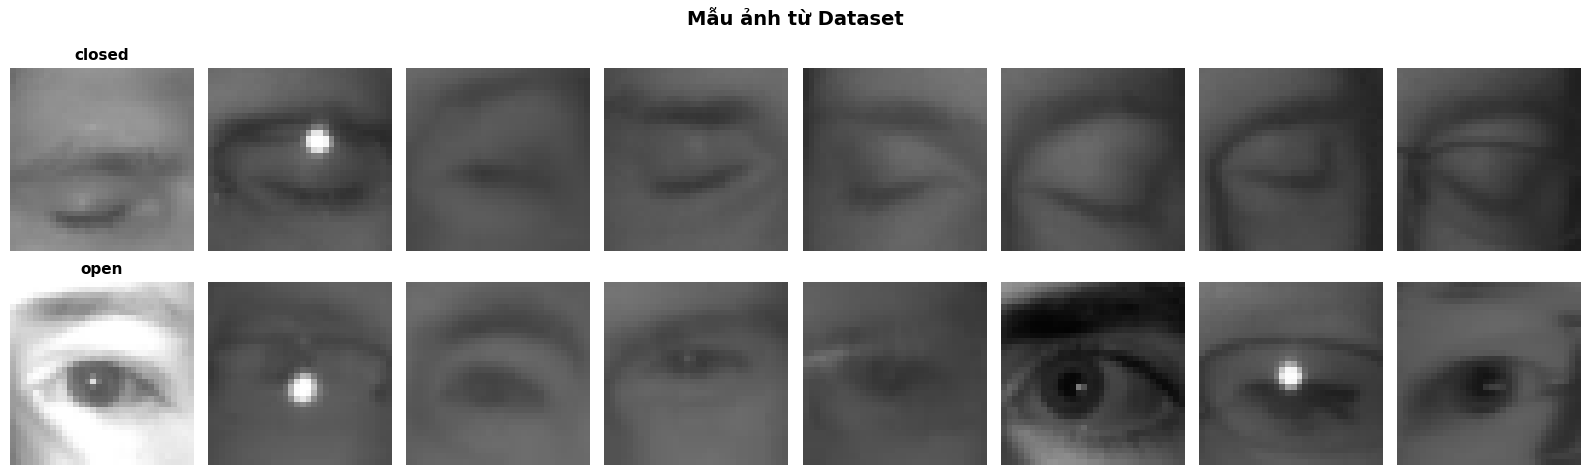

In [ ]:
# Hiển thị mẫu ảnh từ dataset
y_raw_vis = np.argmax(y, axis=1)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Mẫu ảnh từ Dataset', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_indices = np.where(y_raw_vis == cls_idx)[0][:8]
    for col, img_idx in enumerate(cls_indices):
        axes[cls_idx][col].imshow(X[img_idx])
        axes[cls_idx][col].axis('off')
        if col == 0:
            axes[cls_idx][col].set_title(cls_name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def split_dataset(X, y):
    print('\nChia train/val/test (70/20/10)...')
    y_int = np.argmax(y, axis=1)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y_int
    )
    y_temp_int = np.argmax(y_temp, axis=1)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp_int
    )

    print(f'  Train : {len(X_train)} ảnh')
    print(f'  Val   : {len(X_val)} ảnh')
    print(f'  Test  : {len(X_test)} ảnh')
    return X_train, X_val, X_test, y_train, y_val, y_test


def create_data_generators(X_train, y_train, X_val, y_val, X_test, y_test):
    print('\nTạo data generators với augmentation...')

    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        return image, label

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(buffer_size=len(X_train), seed=42)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )
    test_ds = (
        tf.data.Dataset.from_tensor_slices((X_test, y_test))
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )
    print('  ✅ Data generators sẵn sàng')
    return train_ds, val_ds, test_ds


X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
train_ds, val_ds, test_ds = create_data_generators(X_train, y_train, X_val, y_val, X_test, y_test)


Chia train/val/test (70/20/10)...
  Train : 7000 ảnh
  Val   : 2000 ảnh
  Test  : 1000 ảnh

Tạo data generators với augmentation...
  ✅ Data generators sẵn sàng


## 🏗️ BƯỚC 4 (Phần 2): Xây dựng Model

In [ ]:
def build_model():
    print('\n' + '='*60)
    print('PHẦN 2: XÂY DỰNG MODEL')
    print('='*60)

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        alpha=ALPHA,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    print(f'  Base model: MobileNetV2 alpha={ALPHA}')
    print(f'  Số layer đóng băng: {len(base_model.layers)}')

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_eye')
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x       = layers.Dense(64, activation='relu', name='dense_64')(x)
    x       = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='EyeStateDetector')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    total_params     = model.count_params()
    trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'\n  Tổng tham số      : {total_params:,}')
    print(f'  Tham số trainable : {trainable_params:,}')
    model.summary()
    return model


model = build_model()


PHẦN 2: XÂY DỰNG MODEL


/tmp/ipykernel_3101/2788074867.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Base model: MobileNetV2 alpha=0.35
  Số layer đóng băng: 154

  Tổng tham số      : 492,322
  Tham số trainable : 82,114


Model: "EyeStateDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_eye (InputLayer)          │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_224            │ (None, 1, 1, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,322 (1.88 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 410,208 (1.56 MB)

## 🚀 BƯỚC 5 (Phần 3): Train Model

In [ ]:
def create_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=str(BEST_MODEL_PATH), monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2,
            min_lr=1e-6, verbose=1
        ),
    ]


print('\n' + '='*60)
print('PHẦN 3: TRAIN MODEL')
print('='*60)
print(f'  Epochs tối đa : {EPOCHS}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Learning rate : {LEARNING_RATE}')

start_time = time.time()
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=create_callbacks(),
    verbose=1
)
elapsed = time.time() - start_time
print(f'\n✅ Training hoàn thành trong {elapsed:.1f} giây ({elapsed/60:.1f} phút)')


PHẦN 3: TRAIN MODEL
  Epochs tối đa : 10
  Batch size    : 64
  Learning rate : 0.001
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6796 - loss: 0.6270
Epoch 1: val_accuracy improved from None to 0.78900, saving model to /content/models/eye_model_best.h5



Epoch 1: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 229ms/step - accuracy: 0.7443 - loss: 0.5662 - val_accuracy: 0.7890 - val_loss: 0.4704 - learning_rate: 0.0010
Epoch 2/10
104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7885 - loss: 0.4721
Epoch 2: val_accuracy improved from 0.78900 to 0.80750, saving model to /content/models/eye_model_best.h5



Epoch 2: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7959 - loss: 0.4548 - val_accuracy: 0.8075 - val_loss: 0.4205 - learning_rate: 0.0010
Epoch 3/10
105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8145 - loss: 0.4203
Epoch 3: val_accuracy improved from 0.80750 to 0.82100, saving model to /content/models/eye_model_best.h5



Epoch 3: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8160 - loss: 0.4128 - val_accuracy: 0.8210 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 4/10
105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8230 - loss: 0.3996
Epoch 4: val_accuracy did not improve from 0.82100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8156 - loss: 0.4059 - val_accuracy: 0.8190 - val_loss: 0.3959 - learning_rate: 0.0010
Epoch 5/10
106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8321 - loss: 0.3898
Epoch 5: val_accuracy improved from 0.82100 to 0.82200, saving model to /content/models/eye_model_best.h5



Epoch 5: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8246 - loss: 0.3939 - val_accuracy: 0.8220 - val_loss: 0.3892 - learning_rate: 0.0010
Epoch 6/10
106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8330 - loss: 0.3891
Epoch 6: val_accuracy did not improve from 0.82200
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8303 - loss: 0.3868 - val_accuracy: 0.8215 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8311 - loss: 0.3830
Epoch 7: val_accuracy improved from 0.82200 to 0.82550, saving model to /content/models/eye_model_best.h5



Epoch 7: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8314 - loss: 0.3810 - val_accuracy: 0.8255 - val_loss: 0.3790 - learning_rate: 0.0010
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8249 - loss: 0.3898
Epoch 8: val_accuracy improved from 0.82550 to 0.82850, saving model to /content/models/eye_model_best.h5



Epoch 8: finished saving model to /content/models/eye_model_best.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8330 - loss: 0.3780 - val_accuracy: 0.8285 - val_loss: 0.3783 - learning_rate: 0.0010
Epoch 9/10
105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8395 - loss: 0.3702
Epoch 9: val_accuracy did not improve from 0.82850
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8393 - loss: 0.3722 - val_accuracy: 0.8265 - val_loss: 0.3751 - learning_rate: 0.0010
Epoch 10/10
102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8367 - loss: 0.3677
Epoch 10: val_accuracy did not improve from 0.82850
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8351 - loss: 0.3723 - val_accuracy: 0.8250 - val_loss: 0.3730 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

✅ Training hoàn thành trong 53.5 giây (0.9 phút)


## 📊 BƯỚC 6 (Phần 4): Đánh giá Model

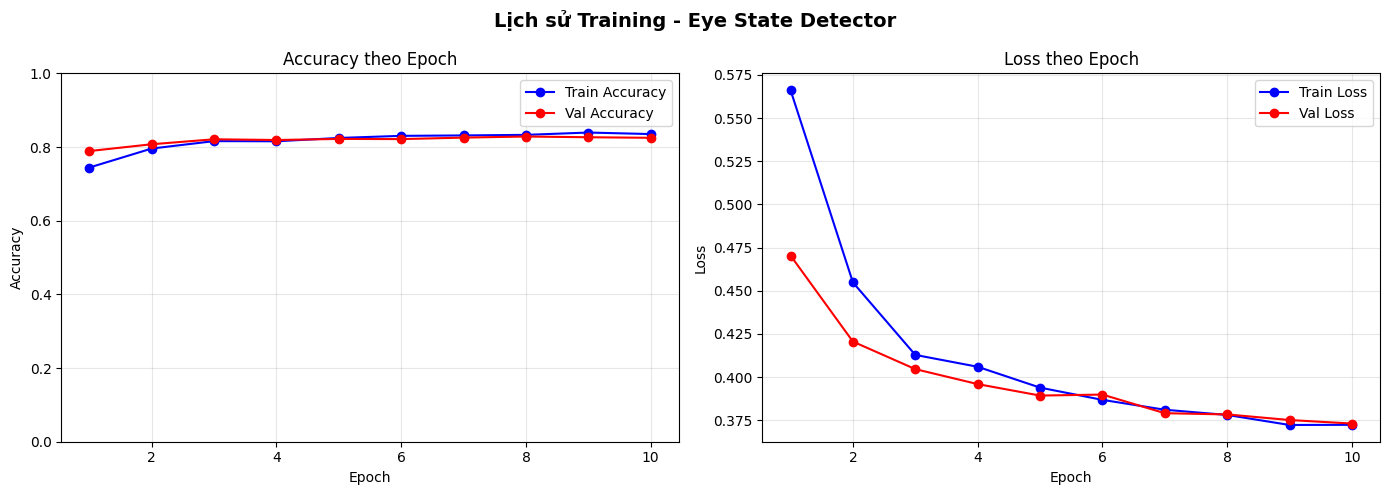

✅ Đã lưu biểu đồ training


In [ ]:
# Biểu đồ Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lịch sử Training - Eye State Detector', fontsize=14, fontweight='bold')

ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],     'b-o', label='Train Accuracy')
axes[0].plot(ep, history.history['val_accuracy'], 'r-o', label='Val Accuracy')
axes[0].set_title('Accuracy theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(ep, history.history['loss'],     'b-o', label='Train Loss')
axes[1].plot(ep, history.history['val_loss'], 'r-o', label='Val Loss')
axes[1].set_title('Loss theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ training')


PHẦN 4: ĐÁNH GIÁ MODEL

Test Loss     : 0.3906
Test Accuracy : 0.8290  (82.90%)

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      closed       0.80      0.87      0.84       500
        open       0.86      0.78      0.82       500

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



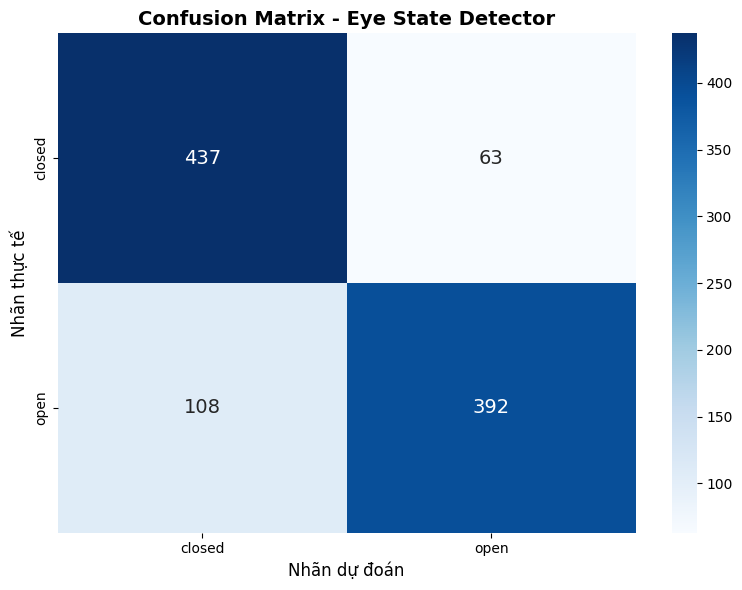

✅ Đã lưu confusion matrix


In [ ]:
print('\n' + '='*60)
print('PHẦN 4: ĐÁNH GIÁ MODEL')
print('='*60)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

y_pred_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print('-' * 50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    annot_kws={'size': 14}
)
plt.title('Confusion Matrix - Eye State Detector', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn thực tế', fontsize=12)
plt.xlabel('Nhãn dự đoán', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu confusion matrix')

## 💾 BƯỚC 7 (Phần 5): Export Model

In [ ]:
print('\n' + '='*60)
print('PHẦN 5: EXPORT MODEL')
print('='*60)

# --- Lưu .h5 ---
model.save(str(MODEL_H5_PATH))
h5_size = MODEL_H5_PATH.stat().st_size / 1024
print(f'\n✅ Đã lưu .h5     : {MODEL_H5_PATH}  ({h5_size:.1f} KB)')

# --- Convert sang TFLite Float16 ---
print('\nĐang convert sang TFLite (Float16 quantization)...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

def representative_dataset_gen():
    sample_size = min(100, len(X_train))
    indices = np.random.choice(len(X_train), sample_size, replace=False)
    for idx in indices:
        yield [X_train[idx:idx+1].astype(np.float32)]

converter.representative_dataset = representative_dataset_gen

try:
    tflite_model = converter.convert()
    with open(MODEL_TFLITE_PATH, 'wb') as f:
        f.write(tflite_model)
    tflite_size = MODEL_TFLITE_PATH.stat().st_size / 1024
    reduction = (1 - tflite_size / h5_size) * 100
    print(f'\n✅ Đã lưu .tflite : {MODEL_TFLITE_PATH}  ({tflite_size:.1f} KB)')
    print(f'\n📊 So sánh kích thước:')
    print(f'   .h5    : {h5_size:.1f} KB')
    print(f'   .tflite: {tflite_size:.1f} KB  (giảm {reduction:.1f}%)')
except Exception as e:
    print(f'[LỖI] {e} — thử convert không quantize...')
    converter_basic = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter_basic.convert()
    with open(MODEL_TFLITE_PATH, 'wb') as f:
        f.write(tflite_model)
    print(f'✅ Đã lưu .tflite (không quantize)')


PHẦN 5: EXPORT MODEL

✅ Đã lưu .h5     : /content/models/eye_model.h5  (2928.0 KB)

Đang convert sang TFLite (Float16 quantization)...
Saved artifact at '/tmp/tmp59y6nosx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_eye')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134601034899408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134596341516240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134596341516432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134598504087376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134598504087184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134598504078544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134596341516624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134596341517392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134596341517008: Tensor

## ⬇️ BƯỚC 8: Tải file model về máy tính

In [ ]:
# Liệt kê tất cả file đã tạo
print('📁 Các file trong /content/models/:')
for f in MODEL_DIR.iterdir():
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:<35} {size_kb:>8.1f} KB')

📁 Các file trong /content/models/:
   eye_model.tflite                       970.4 KB
   confusion_matrix.png                    44.8 KB
   sample_images.png                       40.7 KB
   training_history.png                    88.6 KB
   eye_model_best.h5                     2928.0 KB
   eye_model.h5                          2928.0 KB


In [ ]:
# Nén toàn bộ thư mục models/ thành 1 file zip để tải về
import shutil

zip_path = '/content/eye_model_output'
shutil.make_archive(zip_path, 'zip', '/content/models')
print(f'✅ Đã nén xong: {zip_path}.zip')

# Tải về máy tính
from google.colab import files
files.download(f'{zip_path}.zip')
print('⬇️  Đang tải file về máy...')

✅ Đã nén xong: /content/eye_model_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Đang tải file về máy...


In [ ]:
# (Tuỳ chọn) Tải riêng từng file nếu muốn
# files.download(str(MODEL_H5_PATH))
# files.download(str(MODEL_TFLITE_PATH))
# files.download(str(BEST_MODEL_PATH))

print('\n' + '='*60)
print('✅ HOÀN THÀNH! Tóm tắt:')
print('='*60)
print(f'  eye_model.h5          → dùng với Keras/TensorFlow')
print(f'  eye_model.tflite      → dùng với Raspberry Pi / Edge device')
print(f'  eye_model_best.h5     → model có val_accuracy cao nhất')
print(f'  training_history.png  → biểu đồ accuracy & loss')
print(f'  confusion_matrix.png  → ma trận nhầm lẫn')
print('='*60)